<a href="https://colab.research.google.com/github/renanwta/Red-Wine/blob/main/Red_Wine_Reebuiding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library

In [1]:
# Bibliotecas

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Crating Pipeline with imblearn
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# Criação de modelo treino e teste
from sklearn.model_selection import train_test_split

# Modelos de Machine Learning
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Pré processamento dos dados
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import FunctionTransformer
from imblearn.over_sampling import ADASYN,SMOTE

# Métricas para validação
from sklearn import metrics
from sklearn.metrics import precision_score, recall_score,classification_report,accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix

# Evaluation
from sklearn.model_selection import RandomizedSearchCV,cross_val_score,KFold
from sklearn.model_selection import StratifiedKFold
from scipy.stats import randint
from sklearn.model_selection import GridSearchCV



# Uploading the dataset

In [2]:
!kaggle datasets download -d uciml/red-wine-quality-cortez-et-al-2009

Dataset URL: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
License(s): DbCL-1.0
  0% 0.00/25.6k [00:00<?, ?B/s]
100% 25.6k/25.6k [00:00<00:00, 26.9MB/s]


In [3]:
import zipfile

with zipfile.ZipFile('/content/red-wine-quality-cortez-et-al-2009.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')


data = pd.read_csv('/content/winequality-red.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Introduction

## Context

This datasets is related to red variants of the Portuguese "Vinho Verde" wine. For more details, consult the reference [Cortez et al., 2009]. Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

## CRISP-DM

For better development and to avoid potential issues, the project will be developed using the CRISP-DM methodology. This methodology consists of six main stages that guide the development process from understanding and defining the problem to implementation. The stages include:

* Business Understanding
* Data Understanding
* Data Preparation
* Modeling
* Evaluation
* Deployment

Based on the CRISP-DM methodology, the project structure will be organized as follows:

*  Business Understanding
  * Goals

*  Data Understanding
  *  Splitting the dataset
  * Understanding the distribution
  * Looking for the Outliers
  * Looking for the correlations

* Data Preparation
  * Removing the features
  * Tratment of Outliers
  * Looking the distribution features again
  * Binarize target

* Modeling
  * Preprocess of data
    * Creating the variable train and test
    * Creating the pipeline for preprocess
    * Searching the best model
  * Creating the Pipeline
  * Cross validation
  * Tuning

* Evaluation
  * Nested Cross Validation
  * Confusion Matrix
  * Curve Roc

* Deploy

# Business Understanding

The first step of our project is to understand what is our goals, problemns and how we can deal with it.

So first of all, this dataset is related about a variants of a Portuguese red wine called 'Vinho Verde', so to understand more about the quality of these the owner of this dataset made available the characteristic of the wine that he studied and the classification based of theses features.

The main features avaible on this dataset are:
* fixed acidity
* volatile acidity
* citric acid
* residual sugar
* chlorides
* free sulfur dioxide
* total sulfur dioxide
* density
* pH
* sulphates
* alcohol

And the target of this dataset is:
* quality (score between 0 and 10)



About the data set, the author aleged that our dataset is unbalaced, containing majority of our classification 5 and 6

## Goals

* The main objective for this project is to understand the dataset with EDA and a creation Machine Learning model that is capable to predict the quality score of the red wine based by your features.

# Data Understanding

## Splitting the dataset

* Before to make any kind of treatment, analysis or conclusion we need to split our dataset to make sure that we will not have data leakeaged. This steps prevents the contamination of the datas between the train and test datasets

In [4]:
X = data.drop('quality',axis = 1)
y = data.quality

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1337,stratify = y)

Creating our train and test dataset, we wil concat both features and target

In [5]:
data_train = pd.concat((X_train,y_train), axis =1)
data_test = pd.concat((X_test,y_test),axis = 1)

In [6]:
print(X_train.shape)
print(data_train.shape)

(1279, 11)
(1279, 12)


## Understanding the distribution

The data Understanding is the part where use the method of EDA (Exploratory Data Analisys) to get a deep understanding about our dataset, this part of project use graphics and data manipulation make sure what kind of tools we will need to use on data transformer or data preparation.



In [7]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1279 entries, 1466 to 442
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1279 non-null   float64
 1   volatile acidity      1279 non-null   float64
 2   citric acid           1279 non-null   float64
 3   residual sugar        1279 non-null   float64
 4   chlorides             1279 non-null   float64
 5   free sulfur dioxide   1279 non-null   float64
 6   total sulfur dioxide  1279 non-null   float64
 7   density               1279 non-null   float64
 8   pH                    1279 non-null   float64
 9   sulphates             1279 non-null   float64
 10  alcohol               1279 non-null   float64
 11  quality               1279 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 129.9 KB


In [8]:
data_train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.00000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000
mean,8.302502,0.524398,0.272033,2.524081,0.088001,16.03792,46.433933,0.996711,3.311642,0.656630,10.439367,5.637217
std,1.736867,0.179503,0.193401,1.338703,0.049307,10.63934,32.499761,0.001861,0.154581,0.165067,1.078125,0.808633
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.00000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.100000,1.900000,0.070000,7.00000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.00000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.632500,0.420000,2.600000,0.090000,22.00000,62.000000,0.997800,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.400000,0.611000,72.00000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Insight

* Looking the results of info(), we can see that ou dataset only have numeric features and our target is classification;

* on the describe, we can see that at 25%, 50% and 75% of our dataset have a presence of classification 5 and 6 majority what means that our dataset is unbalaced.

Creating our histogram

* making it easy, we created a dictionary for our features and target, and than we created a double loop to make sure tahr ou histogram will be fitted on our matrix of plots.

In [9]:
dic = {0:'fixed acidity',
1:'volatile acidity',
2: 'citric acid',
3: 'residual sugar',
4: 'chlorides',
5:'free sulfur dioxide',
6: 'total sulfur dioxide',
7:'density',
8:'pH',
9:'sulphates',
10: 'alcohol',
11: 'quality'
}

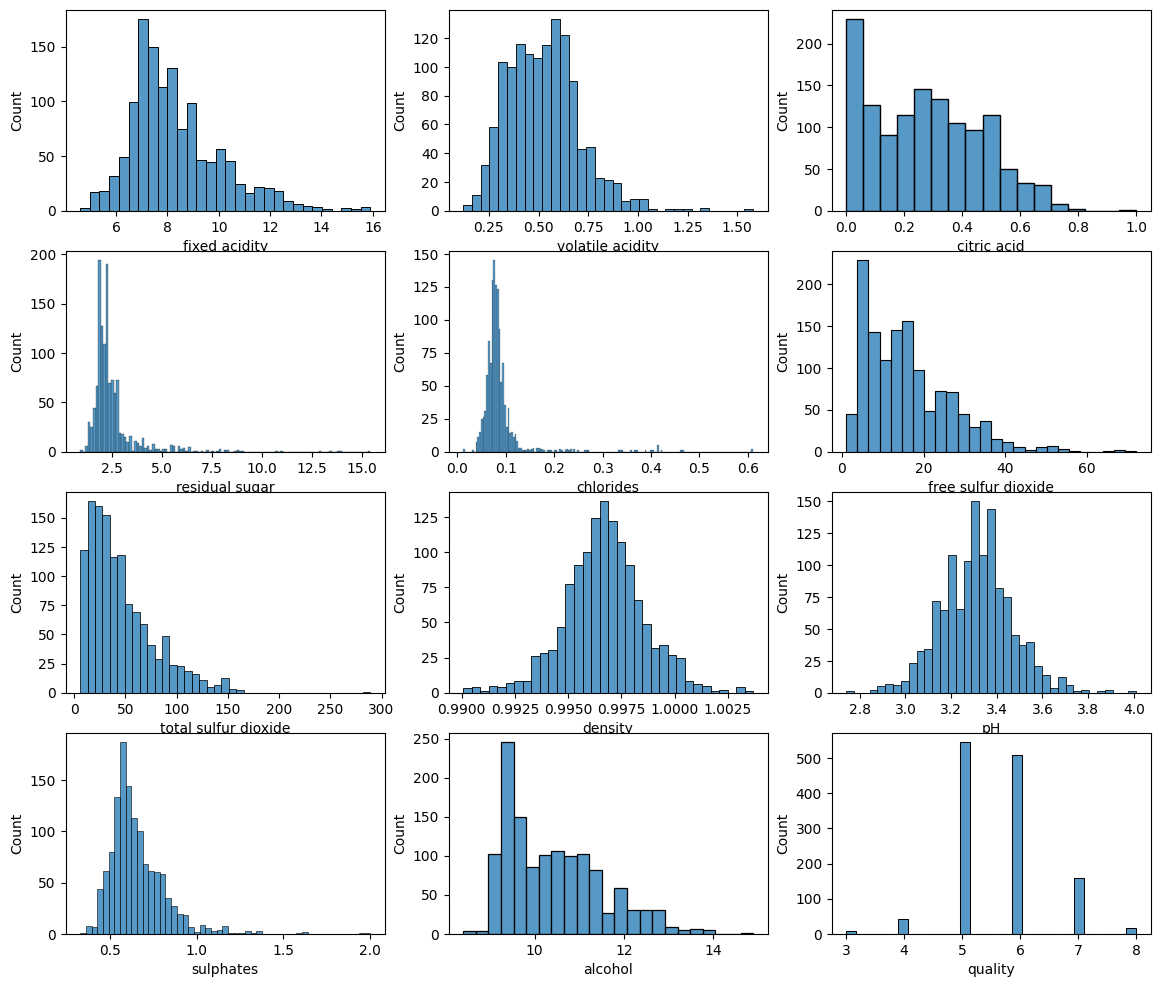

In [10]:
fig, axs = plt.subplots(4,3,figsize = (14, 12))
num = 0

for i in range(4):
  for j in range(3):
    sns.histplot(data = data_train,x = data_train[dic[num]], ax = axs[i][j])
    num +=1

Insights

* Examining the histogram above, we can see a pattern on the distribution of our data, where that is possible to see that our data follow the normal distributio by left;

* Also, we can see by the histogram and the describe, that our dataset have many different unit of measurement, that means that on our preprocess step we need to use StandardScaler to make sure that our ML model will be fine;

* We can see that all of out histogram have a tail on the right, it means that ou data probably have a outliers, and we will see it on the next step.

## Looking for the Outliers

To looking for outliers we will use the boxplots, so to make it easy we will use the same dictionary where we use before.

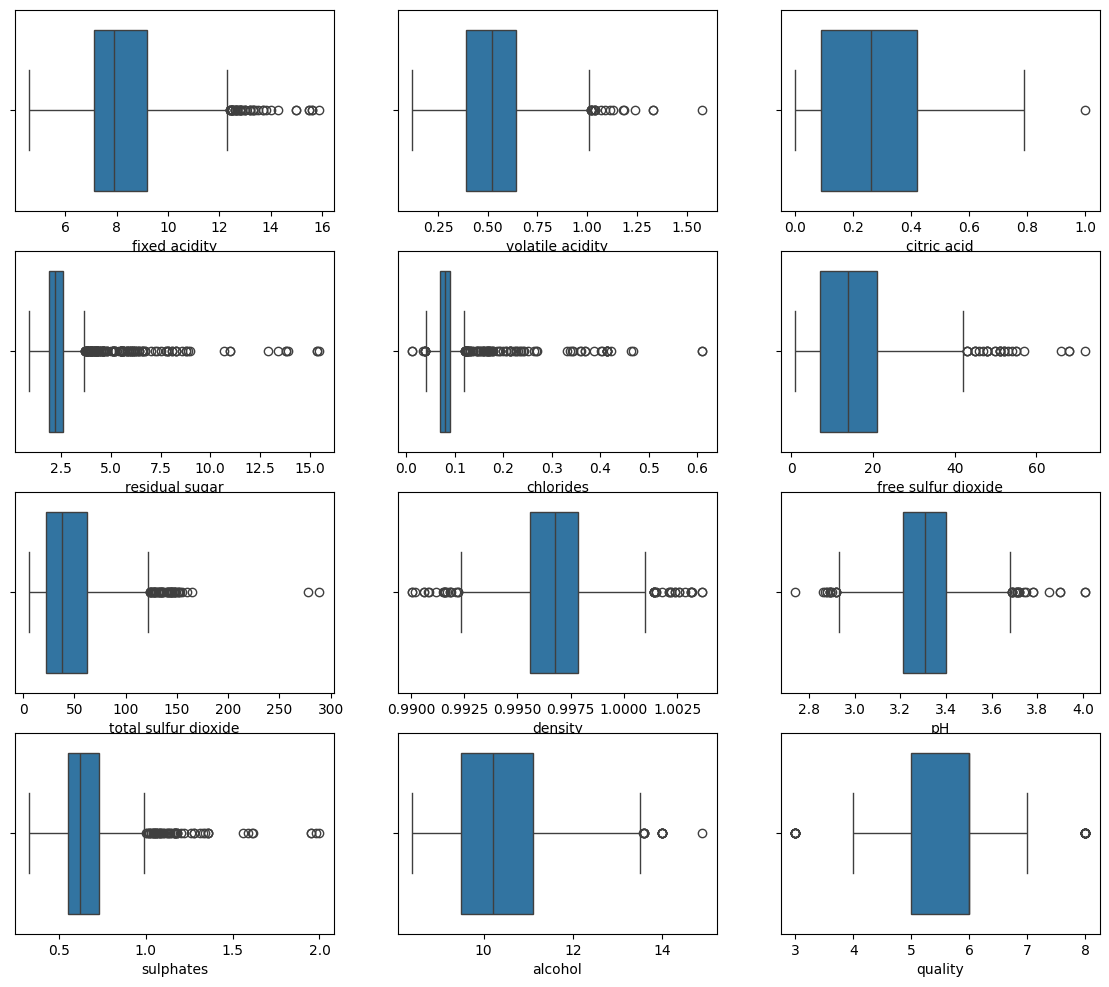

In [11]:
fig, axs = plt.subplots(4,3,figsize = (14, 12))
num = 0

for i in range(4):
  for j in range(3):
    sns.boxplot(data = data_train,x = data[dic[num]], ax = axs[i][j])
    num +=1

Analysis

* Analysing out boxplots above, we see that our dataset presenting outliers almost in all features, so we need to make sure to remove all of this outliers.

## Looking the correlation

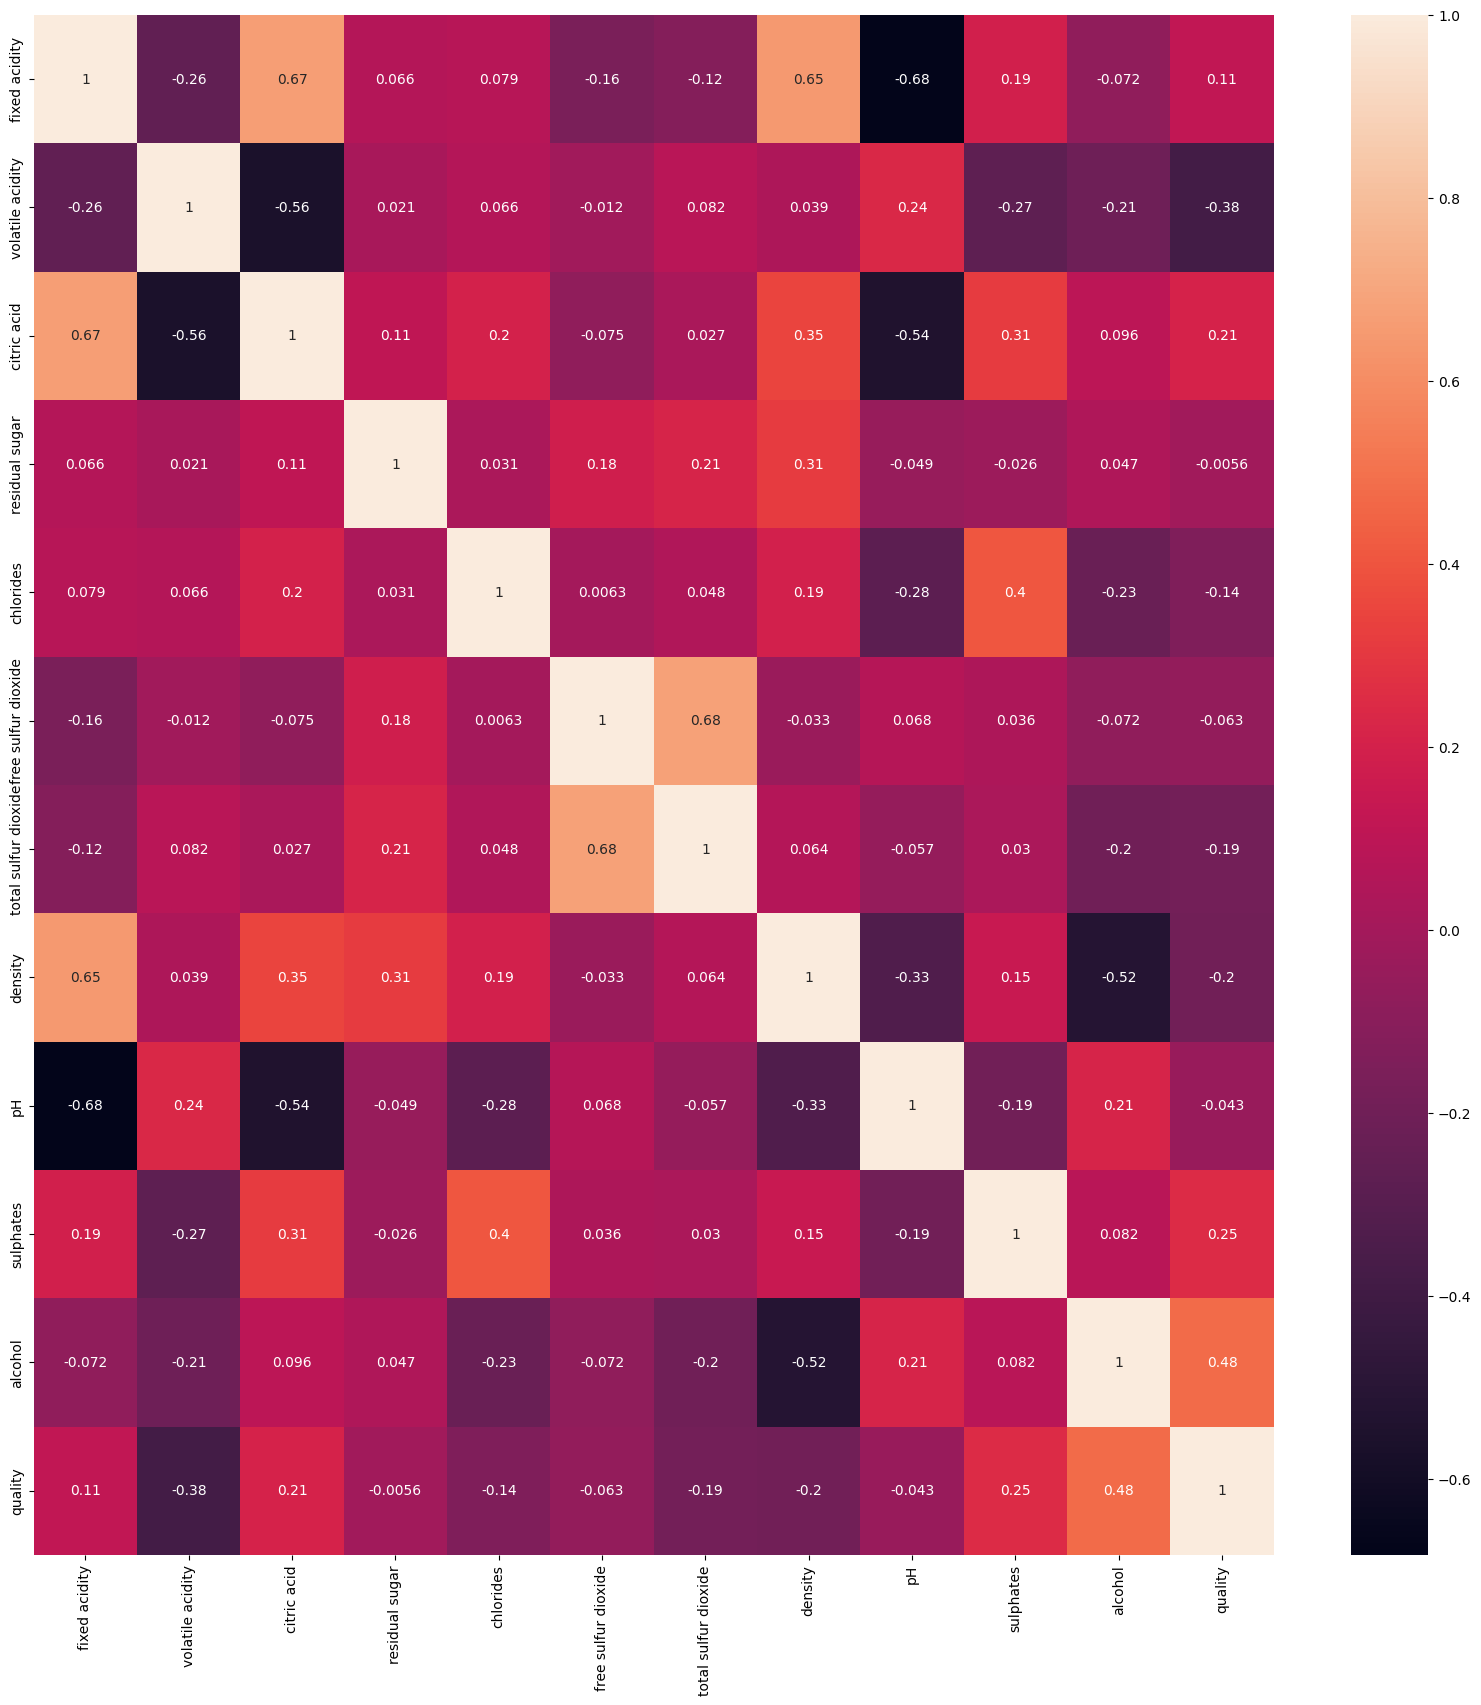

In [12]:
corr = data_train.corr()
fig,ax = plt.subplots(figsize = (20,20))
ax = sns.heatmap(corr, annot = True)

Analysis

* Observing the correlation matrix, we can see the main variable who is correlated with the target 'quality' like 'alcohol', 'sulphates' and 'citric acid' is features that is positive correlation with the target and 'volatile acidity' and  'total sulfur dioxide' are negative relation with the target.

* Looking the correlation between the features, we can see the feature 'fixe acidity' have a highly correlation with 'pH' and 'density',
also the 'free sufur dioxide' is highly correlated with 'total sufur dioxide'.

* The feature to be remove is 'ph','density','free sufur dioxide','chlorides'

# Data Preparation

Out next steps will be compose by some steps for data preparation, the first one is to recreate the dataset train and test with the features that don't have a high corelation between them, the next steps is to remove all outliers from our dataset, lastly is to preprocess our dataset, making sure that our dataset get read for machine learning.

## Removing the features

The part of removing the features can't be done once, so we need to create a pipeline with a funciont transform to make sure that the futures data will be changed with tha pipeline.

In [13]:
def remove_features(X):
  return X.drop(columns = ['chlorides','pH','density','free sulfur dioxide'], axis = 1)

remove_features_transform = FunctionTransformer(remove_features)


data_train = remove_features_transform.transform(data_train)
data_test = remove_features_transform.transform(data_test)

## Treatment of outliers

* To make these treatment of outliers, we'll create a function that make this treatment to each featues of our dataset;

* the method to use to remove the outliers is the Inter Quartile Range (IQR).

In [14]:
dic_iqr = {0:'fixed acidity',
1:'volatile acidity',
2: 'citric acid',
3: 'residual sugar',
4: 'total sulfur dioxide',
5:'sulphates',
6: 'alcohol',
7: 'quality'
}
data_train_out = data_train.copy()

for col in data_train_out.columns:
  q1 = data_train[col].quantile(0.25)
  q3 = data_train[col].quantile(0.75)
  iqr = q3-q1

  upper_limit = q3 + (1.4 * iqr)
  lower_limit = q1 - (1.4 * iqr)

  data_train_out = data_train_out.loc[(data_train_out[col] < upper_limit) & (data_train_out[col] > lower_limit)]

In [15]:
data_train_out.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,total sulfur dioxide,sulphates,alcohol,quality
1466,7.3,0.480,0.32,2.1,54.0,0.65,10.00,7
1272,5.9,0.460,0.00,1.9,44.0,0.53,11.20,5
1396,8.7,0.675,0.10,1.6,11.0,0.65,9.55,5
948,8.9,0.120,0.45,1.8,21.0,0.76,11.90,7
666,8.3,0.490,0.36,1.8,16.0,0.60,9.50,6


Observing again the boxplots

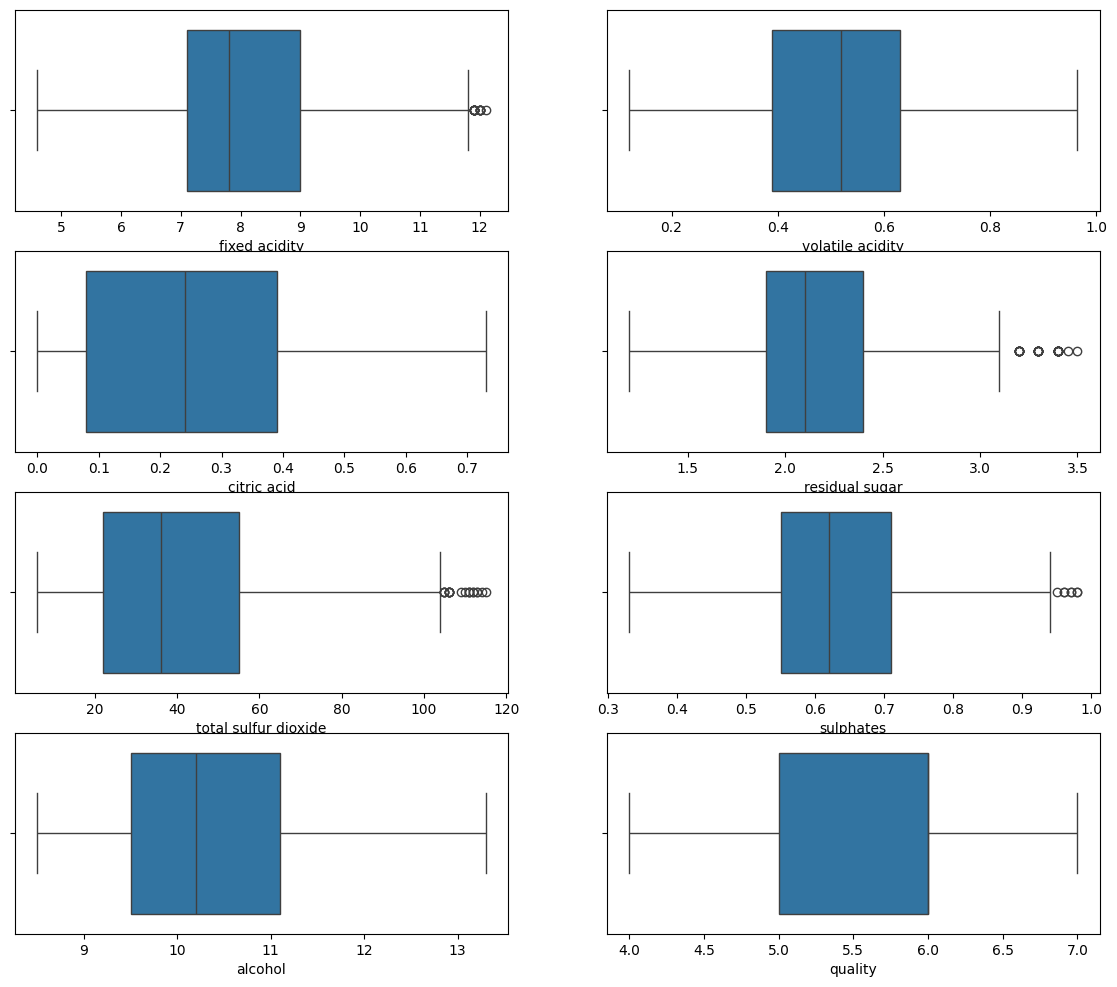

In [16]:
fig, axs = plt.subplots(4,2,figsize = (14, 12))
num = 0

for i in range(4):
  for j in range(2):
    sns.boxplot(data = data_train_out,x = data_train_out[dic_iqr[num]], ax = axs[i][j])
    num +=1

Insight

* Obseverving both boxplots before and after, we see a huge diference of outliers in some of features like 'residual sugar', 'fixed acidity' and 'sulphates', those features was who get more efficience to remove outliers but not remove all of them;

* The all other features also get a good improvement of removing the outliers, some of than like 'alcohol' and 'volatile acidity' doesn't have outliers anymore;

* Now, looking at the target, we didn't use the IQR method, but we can see that by improving the other features, the target variable was also improved;

* Observing the code where we did the IQR treatment we can see that the *k* value is 1.4 insted of 1.5, this values make our IQR more restrict to take off more outliers from our data set.

## Looking the distribution features again


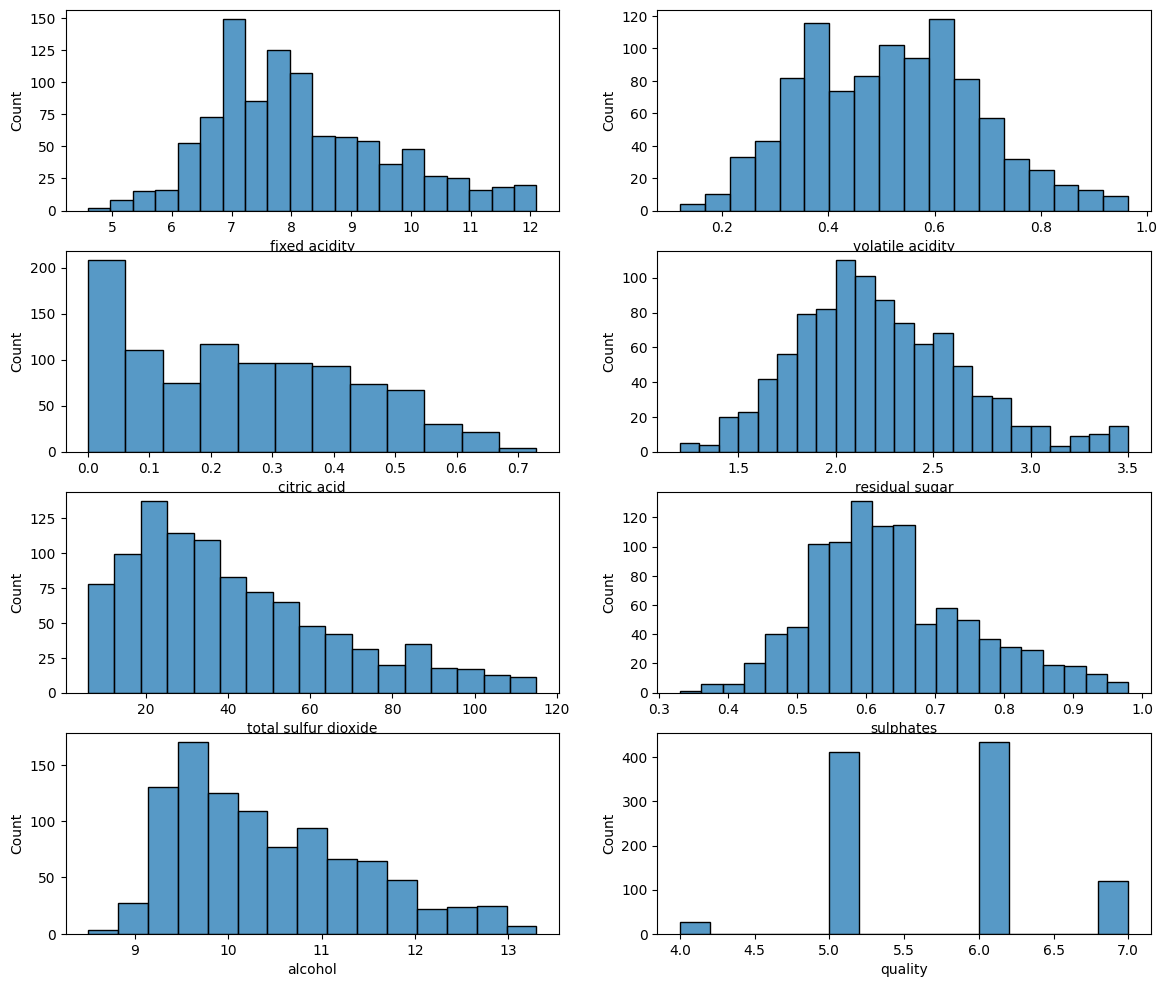

In [17]:
fig, axs = plt.subplots(4,2,figsize = (14, 12))
num = 0

for i in range(4):
  for j in range(2):
    sns.histplot(data = data_train_out,x = data_train_out[dic_iqr[num]], ax = axs[i][j])
    num +=1

Analysis

* Now looking for the distribuition of our dataset, we can see that the features are normaly distribution, so for preprocesses stpes we are allow to use StandardScaler to make sure that our data become normalized.

## Binarize target

In [18]:
def binarize_target(X):

  X['quality'] = [1 if X >= 7 else 0 for X in X['quality']]
  return X

binarize_target_transform = FunctionTransformer(binarize_target)

data_train_out_bin = binarize_target_transform.transform(data_train_out)
data_test_out_bin = binarize_target_transform.transform(data_test)

In [19]:
data_train_out_bin

,fixed acidity,volatile acidity,citric acid,residual sugar,total sulfur dioxide,sulphates,alcohol,quality
1466,7.3,0.480,0.32,2.10,54.0,0.65,10.00,1
1272,5.9,0.460,0.00,1.90,44.0,0.53,11.20,0
1396,8.7,0.675,0.10,1.60,11.0,0.65,9.55,0
948,8.9,0.120,0.45,1.80,21.0,0.76,11.90,1
666,8.3,0.490,0.36,1.80,16.0,0.60,9.50,0
...,...,...,...,...,...,...,...,...
1171,7.1,0.590,0.00,2.20,44.0,0.68,10.80,0
315,7.1,0.350,0.29,2.50,53.0,0.65,11.00,0
991,7.1,0.340,0.28,2.00,68.0,0.48,9.40,0
303,7.4,0.670,0.12,1.60,21.0,0.54,9.50,0


#Modeling

the currently step is for creating our preprocess data and creation of our model, but first of all, we will create a functin that we can used it to see wich model is better for our problem.

## Preprocess

In [20]:
models = {'SVC':SVC(),
          'RandomForestClassifier':RandomForestClassifier(),
          'DecisionTreeClassifier' : DecisionTreeClassifier(),
          'KNN Classifier' : KNeighborsClassifier(),
          'LogisticRegression' : LogisticRegression(),
          'XGBClassifeir':XGBClassifier()
          }

### Creating the variable train and test

In [21]:
X_train = data_train_out_bin.drop('quality', axis =1 )
y_train = data_train_out_bin.quality

X_test = data_test_out_bin.drop('quality', axis =1 )
y_test = data_test_out_bin.quality

### Creating the pipeline for preprocess (Columns Transform)

In [22]:
dic_col = [
'fixed acidity',
'volatile acidity',
 'citric acid',
 'residual sugar',
 'total sulfur dioxide',
'sulphates',
'alcohol']

target= ['quality']

pp_transform = ColumnTransformer(
    transformers = [
        ('num',StandardScaler(),dic_col)
    ]
)

smote = SMOTE(sampling_strategy=0.8, k_neighbors=5)

Analisys

* the fact that we only used StandardScalred for our Columns Transformer is beacuse our dataset only have a numeric features.

### Searching the best model

In this part of the preprocessing, we are creating a function that generates machine learning models for each type we previously selected. We then create a classification report to simplify the process of selecting the best model

In [23]:
def modelos_testes (models,X_train,y_train,X_test,y_test):
  for model_name, modelos in models.items():
    print(30*'--')
    print(model_name)
    print(30*'--')
    smote = SMOTE(sampling_strategy=0.8, k_neighbors=5)
    pp_transform = ColumnTransformer(
    transformers = [
        ('num',StandardScaler(),dic_col)
        ]
    )
    pipeline = ImbPipeline(
    steps=[
        ('smote',smote),
        ('pp',pp_transform),
        ('modelo',modelos)
        ]
    )

    pipeline.fit(X_train, y_train)
    y_train_pred = pipeline.predict(X_test)
    print(classification_report(y_test,y_train_pred))

In [41]:
modelos_testes(models,X_train,y_train,X_test,y_test)

------------------------------------------------------------
SVC
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       277
           1       0.44      0.56      0.49        43

    accuracy                           0.84       320
   macro avg       0.68      0.72      0.70       320
weighted avg       0.86      0.84      0.85       320

------------------------------------------------------------
RandomForestClassifier
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       277
           1       0.57      0.65      0.61        43

    accuracy                           0.89       320
   macro avg       0.76      0.79      0.77       320
weighted avg       0.89      0.89      0.89       320

------------------------------------------------------------
DecisionTreeCl

* We weill select the Random Forest Classifier as our main model

## Creating the pipeline

Balacing the the dataset of train

In [25]:
smote = SMOTE(random_state = 1337)
X_train_resample,y_train_resample = smote.fit_resample(X_train,y_train)

In [26]:
pipeline = ImbPipeline([
    ('preprocessor', pp_transform),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [27]:
pipeline.fit(X_train_resample,y_train_resample)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['fixed acidity',
                                                   'volatile acidity',
                                                   'citric acid',
                                                   'residual sugar',
                                                   'total sulfur dioxide',
                                                   'sulphates', 'alcohol'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', RandomForestClassifier(random_state=42))])

In [43]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93       277
           1       0.54      0.65      0.59        43

    accuracy                           0.88       320
   macro avg       0.74      0.78      0.76       320
weighted avg       0.89      0.88      0.88       320



Insight

* Despite we have the accuracy score in our classification report, we are nor allowed to use it for validation, the fact is that our target is unbalanced so we need to use others validation's method;

* Also, we can't use this classification report as our main validation way to evaluate our model, the reason why this is best way is the fact that we used all default setting during our traning model, also is necessary use the cros validation to makesure that our model isn't overfitting.

* The fact were we selected the RandomForestClassification as our main model is based on our funcition were we created before, and the selection is based on F1-score, Precission and Recall of each models.

## Cross Validation

the First step in the evaluation part is to check if our model has become overfitted, so we will make a cross validation for our model befor we get a best hiperparameters.

In [29]:
np.randomseed = 1337

inner_cv = StratifiedKFold(n_splits = 10,shuffle = True)

cross_val = cross_val_score(pipeline,X_train_resample,y_train_resample,cv = inner_cv,scoring = 'precision')

print(f'The precision each loop: {cross_val.round(3)}')
print(f'The precision each loop: {np.mean(cross_val.round(2))}')

The precision each loop: [0.914 0.912 0.913 0.887 0.911 0.944 0.867 0.904 0.923 0.933]
The precision each loop: 0.909


Analysis
* Looking the first cross validation, we can see that our models don't have overfitting or underfitting, also it's import to mention again that our data is unbalaced, that means that we need to use as a score the precision.

## Tuning

Our next step is to find out the best hiper paramters in our model, to make it we will  use RandomizedSearchCV to find the best hiperparamters.

In [30]:
paramter_space = {
    'max_depth' : randint(3,32),
    'n_estimators': randint(8,256),
    'min_samples_split':randint(2,20),
    'criterion':['gini', 'entropy', 'log_loss'],
    'class_weight':['balanced','balanced_subsample']
}

In [31]:
best_model = RandomizedSearchCV(
    RandomForestClassifier(),
    paramter_space,
    cv = KFold(n_splits = 10,shuffle = True),
    random_state = 1337,
    n_iter = 15,
    error_score='raise'
)

In [32]:
best_model.fit(X_train,y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=None, shuffle=True),
                   error_score='raise', estimator=RandomForestClassifier(),
                   n_iter=15,
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7954e96336d0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7954ebce3340>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7954e9554460>},
                   random_state=1337)

In [33]:
print(best_model.best_estimator_)

RandomForestClassifier(class_weight='balanced_subsample', criterion='log_loss',
                       max_depth=25, min_samples_split=4, n_estimators=113)


In [34]:
new_pipeline = ImbPipeline([
    ('preprocessor', pp_transform),
    ('smote', SMOTE(random_state=42)),
    ('classifier',RandomForestClassifier(class_weight='balanced_subsample', max_depth=21,
                       min_samples_split=3, n_estimators=181) )
])

new_pipeline.fit(X_train_resample, y_train_resample)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['fixed acidity',
                                                   'volatile acidity',
                                                   'citric acid',
                                                   'residual sugar',
                                                   'total sulfur dioxide',
                                                   'sulphates', 'alcohol'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=21, min_samples_split=3,
                                        n_estimators=181))])

# Evaluated

## Nested Cross Validation

In [45]:
np.randomseed = 1337

outer_cv = StratifiedKFold(n_splits = 10,shuffle = True)

cross_val = cross_val_score(new_pipeline,X_train_resample,y_train_resample,cv = outer_cv,scoring = 'precision')

print(f'The precision each loop: {cross_val.round(3)}')
print(f'The precision each loop: {np.mean(cross_val.round(2))}')

The precision each loop: [0.944 0.871 0.897 0.923 0.954 0.916 0.895 0.966 0.912 0.899]
The precision each loop: 0.917


## Confusion Matrix

In [36]:
y_pred_best = new_pipeline.predict(X_test)

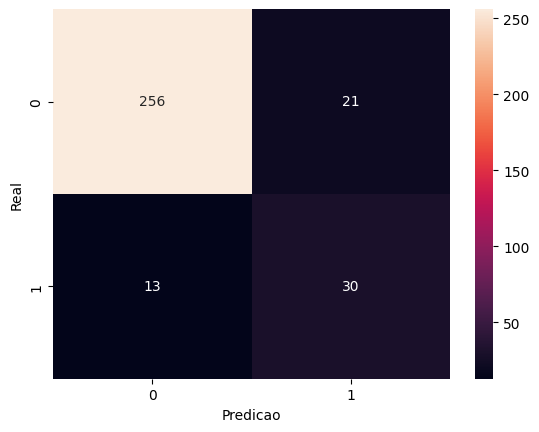

In [37]:
conf = confusion_matrix(y_test, y_pred_best)

sns.heatmap(conf,annot = True, fmt = 'd').set(xlabel = 'Predicao',ylabel = 'Real')
plt.show()

## ROC Curve and AUC

In [38]:
rfc_probs = new_pipeline.predict_proba(X_test)

rfc_probs = rfc_probs[:, 1]


xgb_auc = roc_auc_score(y_test,rfc_probs)
print('RandomForestClassifier AUROC score: {}'.format(xgb_auc.round(3)))


xgb_fpr, xgb_tpr,_ = roc_curve(y_test,rfc_probs)

RandomForestClassifier AUROC score: 0.925


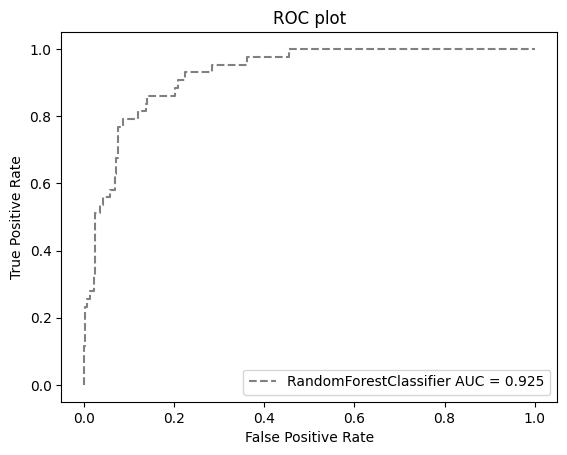

In [44]:
plt.plot(xgb_fpr,xgb_tpr,linestyle = '--',label = 'RandomForestClassifier AUC = {}'.format(xgb_auc.round(3)),color = 'grey')
plt.title('ROC plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Conclusion

* Our Classification Model is great!
* In relation of our goals, our project answered all of our topic, what means that our models is capable to indentify the quality of new wine of 'Vinho Verde';

* In the first time we don't get a really improvement with our RandomSearchCV but we still over 90% of precision in our classification, so it's still good;

* Looking the confusion matrix's plot, we can see that our model is capable to identify quality of the wine even with low quantity of good wine data;

* Regarding the ROC Curve we can see visually that our model have a excellent result separability, with an AUC score above of 0.9 percent. It means that our model is capable to classifie new entries very well;

* About the Nested Cross Validation, our model don't demostrate any kind of overfitting or underfitting, what is great for our results.

* Some observation that we need to relate is the fact that our pre process model passed by smote process, but our data still unbalaced that's why we used the precision as our main scoring for Cross Validation and Nested Cross Validation. Also we understand that for a deployment is interesting to have a SMOTE steps on our pipeline, therefore, even with SMOTE's process was a separeted process for a fitting part of our model, we keeped the process in our final pipeline.